# Project 1: Automatic Review Analyzer

This notebook accompanies the Unit 1 project and reproduces the main experimental ideas behind the research used to motivate the project.

We compare three linear classifiers for binary review classification:

- Perceptron
- Average Perceptron
- Pegasos

The reusable implementations live in `review_analyzer.py`. This notebook is the experimental and visualization layer.

## 1. Imports and project setup

In [1]:
from pathlib import Path
import sys
import unittest

import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "project_1":
    candidate = PROJECT_DIR / "unit_1" / "project_1"
    if candidate.exists():
        PROJECT_DIR = candidate
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from review_analyzer import (
    Review,
    accuracy,
    average_perceptron,
    build_vocabulary,
    pegasos,
    perceptron,
    vectorize,
)


## 2. Toy review dataset

The toy dataset is deliberately small so that the mechanics of the classifiers can be inspected directly. It is a demonstration dataset, not a basis for statistical conclusions.

In [2]:
reviews = [
    Review(1, "great product"),
    Review(1, "excellent product"),
    Review(1, "good value"),
    Review(-1, "bad product"),
    Review(-1, "terrible product"),
    Review(-1, "poor value"),
]

vocabulary = build_vocabulary(reviews)
data = vectorize(reviews, vocabulary)

print(f"Vocabulary size: {len(vocabulary)}")
print(f"Training examples: {len(data)}")


Vocabulary size: 8
Training examples: 6


In [3]:
print("Learned vocabulary:\n")
for word, index in vocabulary.items():
    print(f"{word:12} -> {index}")


Learned vocabulary:

bad          -> 0
excellent    -> 1
good         -> 2
great        -> 3
poor         -> 4
product      -> 5
terrible     -> 6
value        -> 7


## 3. Run the three classifiers

The project implements sparse linear classifiers. Pegasos uses the stochastic sub-gradient method for the regularized primal SVM objective.

In [4]:
models = {
    "Perceptron": perceptron(data, epochs=10),
    "Average perceptron": average_perceptron(data, epochs=10),
    "Pegasos": pegasos(data, lambda_=1e-3, epochs=20, seed=3),
}

for name, weights in models.items():
    print(f"{name:20} training accuracy: {accuracy(weights, data):.3f}")


Perceptron           training accuracy: 1.000
Average perceptron   training accuracy: 1.000
Pegasos              training accuracy: 1.000


## 4. Training-epoch experiment

To visualize learning, we train each algorithm for increasing numbers of epochs and record training accuracy. This is an empirical illustration of convergence behavior on the toy dataset, not a theoretical convergence proof.

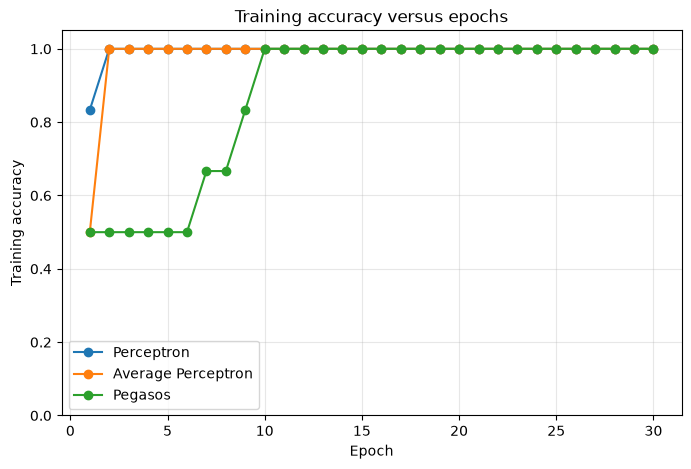

In [5]:
epochs = list(range(1, 31))

perceptron_acc = [accuracy(perceptron(data, epochs=e), data) for e in epochs]
average_acc = [accuracy(average_perceptron(data, epochs=e), data) for e in epochs]
pegasos_acc = [accuracy(pegasos(data, lambda_=1e-3, epochs=e, seed=3), data) for e in epochs]

plt.figure(figsize=(8, 5))
plt.plot(epochs, perceptron_acc, marker="o", label="Perceptron")
plt.plot(epochs, average_acc, marker="o", label="Average Perceptron")
plt.plot(epochs, pegasos_acc, marker="o", label="Pegasos")
plt.xlabel("Epoch")
plt.ylabel("Training accuracy")
plt.title("Training accuracy versus epochs")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 5. Pegasos regularization experiment

The Pegasos objective contains the regularization parameter $\lambda$. We vary $\lambda$ to show how the learned classifier behaves on the same demonstration data.

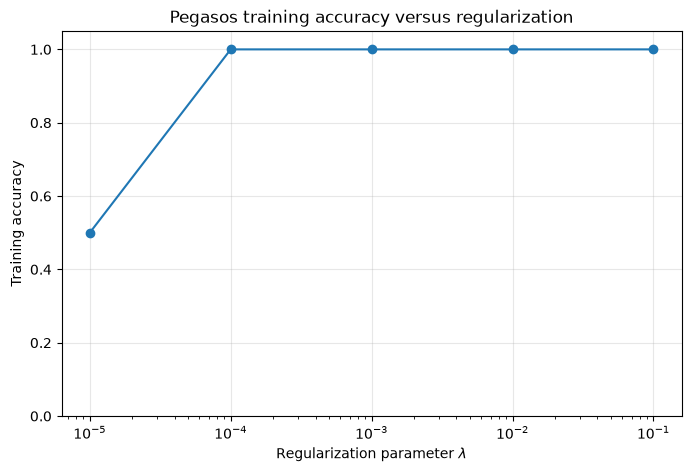

In [6]:
lambdas = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
lambda_acc = []

for lambda_ in lambdas:
    weights = pegasos(data, lambda_=lambda_, epochs=30, seed=3)
    lambda_acc.append(accuracy(weights, data))

plt.figure(figsize=(8, 5))
plt.semilogx(lambdas, lambda_acc, marker="o")
plt.xlabel("Regularization parameter $\\lambda$")
plt.ylabel("Training accuracy")
plt.title("Pegasos training accuracy versus regularization")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()


## 6. Learned word weights

For a linear classifier, each vocabulary word is a feature and therefore receives a learned weight. A positive weight pushes the score toward the positive class, while a negative weight pushes the score toward the negative class. The weight itself is not specific to Pegasos: Perceptron, Average Perceptron, and Pegasos all learn a parameter vector over the same vocabulary.

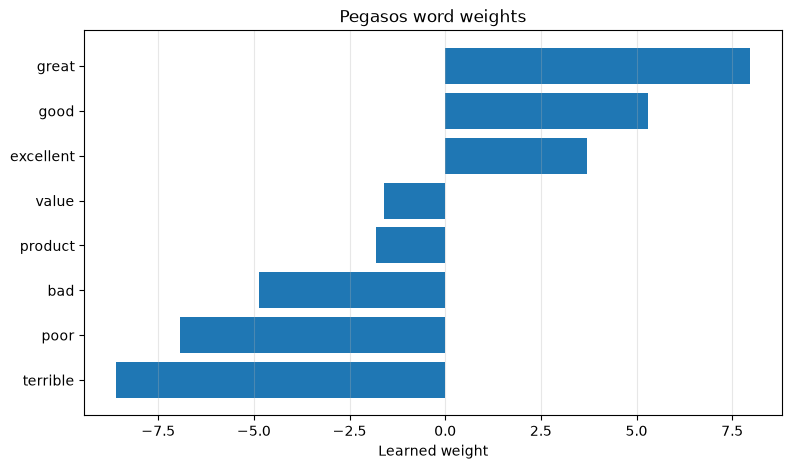

In [7]:
pegasos_weights = pegasos(data, lambda_=1e-3, epochs=30, seed=3)
index_to_word = {index: word for word, index in vocabulary.items()}

ranked = sorted(((index_to_word[index], weight) for index, weight in pegasos_weights.items()), key=lambda item: item[1])
top = ranked[:5] + ranked[-5:]
words = [word for word, _ in top]
weights = [weight for _, weight in top]

plt.figure(figsize=(9, 5))
plt.barh(words, weights)
plt.xlabel("Learned weight")
plt.title("Pegasos word weights")
plt.grid(True, axis="x", alpha=0.3)
plt.show()


### 6.1 Compare word weights across all three classifiers

The same vocabulary is used for all three models, so their parameter vectors can be compared feature by feature. This experiment asks whether the algorithms agree about which words are strongly positive or negative, even though they learn their weights using different update rules.

Because the dataset is tiny, the comparison is qualitative rather than a claim about general sentiment analysis.

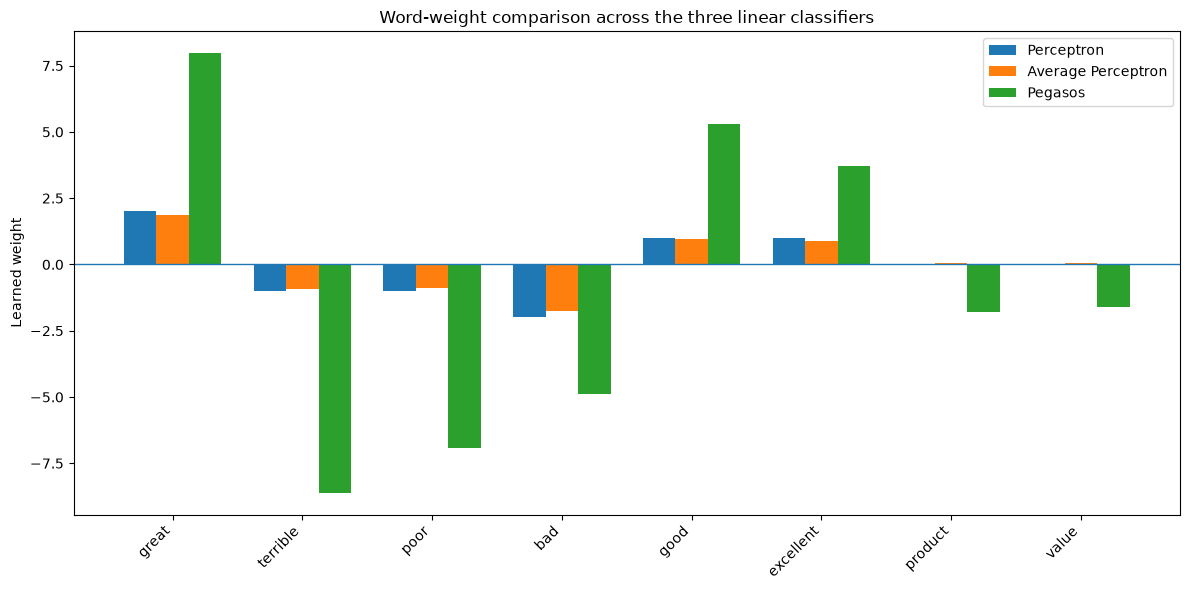

In [8]:
comparison_models = {
    "Perceptron": perceptron(data, epochs=10),
    "Average Perceptron": average_perceptron(data, epochs=10),
    "Pegasos": pegasos(data, lambda_=1e-3, epochs=30, seed=3),
}

all_words = list(vocabulary)

# The implementation uses sparse weight dictionaries. Missing features have
# an implicit weight of zero, so every model must be aligned to the same
# vocabulary before plotting.
aligned_weights = {
    name: [weights.get(vocabulary[word], 0.0) for word in all_words]
    for name, weights in comparison_models.items()
}

mean_abs_weight = {
    word: sum(abs(aligned_weights[name][vocabulary[word]]) for name in aligned_weights)
    / len(aligned_weights)
    for word in all_words
}
selected_words = sorted(all_words, key=mean_abs_weight.get, reverse=True)

# Select the most informative features while keeping x and y the same
# length for every model.
selected_words = selected_words[:min(12, len(selected_words))]
selected_indices = [all_words.index(word) for word in selected_words]

fig, ax = plt.subplots(figsize=(12, 6))
positions = list(range(len(selected_words)))
width = 0.25

for offset, name in enumerate(aligned_weights):
    values = [aligned_weights[name][index] for index in selected_indices]
    assert len(values) == len(positions)
    ax.bar(
        [p + (offset - 1) * width for p in positions],
        values,
        width=width,
        label=name,
    )

ax.set_xticks(positions)
ax.set_xticklabels(selected_words, rotation=45, ha="right")
ax.axhline(0, linewidth=1)
ax.set_ylabel("Learned weight")
ax.set_title("Word-weight comparison across the three linear classifiers")
ax.legend()
plt.tight_layout()
plt.show()


In [9]:
for name, weights in comparison_models.items():
    ranked = sorted(
        ((word, weights.get(vocabulary[word], 0.0)) for word in all_words),
        key=lambda item: item[1],
    )
    print(f"\n{name}")
    print("Most negative:")
    for word, weight in ranked[:3]:
        print(f"  {word:12} {weight:+.4f}")
    print("Most positive:")
    for word, weight in ranked[-3:][::-1]:
        print(f"  {word:12} {weight:+.4f}")



Perceptron
Most negative:
  bad          -2.0000
  poor         -1.0000
  terrible     -1.0000
Most positive:
  great        +2.0000
  good         +1.0000
  excellent    +1.0000

Average Perceptron
Most negative:
  bad          -1.7667
  terrible     -0.9167
  poor         -0.9000
Most positive:
  great        +1.8667
  good         +0.9500
  excellent    +0.8667

Pegasos
Most negative:
  terrible     -8.6045
  poor         -6.9192
  bad          -4.8689
Most positive:
  great        +7.9660
  good         +5.3115
  excellent    +3.7010


In [10]:
print("Sign agreement between learned word weights:")
names = list(comparison_models)
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        left = comparison_models[names[i]]
        right = comparison_models[names[j]]
        agree = sum(
            (left.get(vocabulary[word], 0.0) >= 0) == (right.get(vocabulary[word], 0.0) >= 0)
            for word in all_words
        )
        print(f"  {names[i]} vs {names[j]}: {agree}/{len(all_words)} words")


Sign agreement between learned word weights:
  Perceptron vs Average Perceptron: 8/8 words
  Perceptron vs Pegasos: 6/8 words
  Average Perceptron vs Pegasos: 6/8 words


### Interpretation

- A positive word weight contributes positively to the linear score.
- A negative word weight contributes negatively to the linear score.
- The three algorithms can produce different magnitudes because their learning rules and objectives differ.
- Agreement in the sign of a word's weight is useful evidence that the feature is being used consistently by the models on this dataset.
- Pegasos additionally controls the parameter vector through L2 regularization, but word weights are not a Pegasos-only concept.

## 7. Automated tests

The notebook can also execute the project's unit tests so that the experimental notebook and the reusable implementation are checked together.

In [11]:
suite = unittest.defaultTestLoader.discover(str(PROJECT_DIR), pattern="test_review_analyzer.py")
result = unittest.TextTestRunner(verbosity=2).run(suite)
assert result.wasSuccessful(), "Project tests failed"


test_average_perceptron_learns_toy_data (test_review_analyzer.ReviewAnalyzerTests.test_average_perceptron_learns_toy_data) ... ok
test_end_to_end (test_review_analyzer.ReviewAnalyzerTests.test_end_to_end) ... ok
test_parse_review_line (test_review_analyzer.ReviewAnalyzerTests.test_parse_review_line) ... ok
test_pegasos_batch_update_uses_full_batch_denominator (test_review_analyzer.ReviewAnalyzerTests.test_pegasos_batch_update_uses_full_batch_denominator) ... ok
test_pegasos_is_deterministic_for_fixed_seed (test_review_analyzer.ReviewAnalyzerTests.test_pegasos_is_deterministic_for_fixed_seed) ... ok
test_pegasos_learns_toy_data (test_review_analyzer.ReviewAnalyzerTests.test_pegasos_learns_toy_data) ... ok
test_pegasos_projection_bounds_weight_norm (test_review_analyzer.ReviewAnalyzerTests.test_pegasos_projection_bounds_weight_norm) ... ok
test_perceptron_learns_toy_data (test_review_analyzer.ReviewAnalyzerTests.test_perceptron_learns_toy_data) ... ok
test_sparse_features (test_review_an

## 8. Interpretation

- The toy experiment demonstrates the mechanics of the three linear classifiers.
- Training accuracy alone is not evidence that one method is generally superior.
- The Pegasos experiment illustrates the role of $\lambda$ in the regularized SVM formulation.
- The word-weight comparison shows that interpretability through feature weights applies to all three linear classifiers, not only Pegasos.
- For meaningful research conclusions, the same pipeline should be run on a substantially larger labeled review dataset with a held-out test set.

The notebook therefore serves as a reproducible **demonstration and experimental scaffold**, while the README documents the research motivation and the Python module provides the reusable implementation.